# Bayesian Mixed-Media Model (MMM)
### HAMS Data Science Challenge

---

**Goal:** Understand how each of 7 advertising channels contributes to weekly revenue, accounting for the delayed effect of ads (carry-over / adstock).

**Model structure:**
```
                revenue(t) = baseline + trend(t) + seasonality(t) + sum of channel effects(t) + noise
```

---
**Sections:**
1. Imports
2. Load and explore data
3. Prepare model inputs
4. Adstock function
5. Build the model
6. Prior predictive check
7. Fit with the Markov chain Monte Carlo (MCMC)
8. Convergence check
9. Posterior predictive check + fit metrics
10. Revenue attribution
11. ROI analysis
12. Time-based holdout validation
13. Final summary

---
## 1. Imports

In [111]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import pymc as pm
import pytensor
import pytensor.tensor as pt

RANDOM_SEED = 42

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False
})

---
## 2. Load and Explore the Data

**Dataset:** 104 weeks (~2 years) of weekly revenue and ad spend across 7 channels.

We start with a quick visual inspection:
- Is there a visible trend or seasonal pattern in revenue?
- How does spend vary across channels over time?
- Which channels have the strongest raw correlation with revenue?

> Note: raw correlation can be misleading. A channel that always spends more in Q4 will look correlated with revenue simply because Q4 is a strong sales period. The model below separates these effects properly.

In [107]:
df = pd.read_csv('MMM_test_data.csv')
df['start_of_week'] = pd.to_datetime(df['start_of_week'], format='%d-%m-%y')
df = df.sort_values('start_of_week').reset_index(drop=True)

In [108]:
df.round(0)

,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
0,2020-08-30,157907.0,2625.0,263.0,12954.0,3610.0,12955.0,12659.0,19380.0
1,2020-09-06,186426.0,2634.0,109.0,8760.0,4561.0,12748.0,12338.0,22473.0
2,2020-09-13,161607.0,2087.0,110.0,7155.0,4363.0,15015.0,10811.0,22596.0
3,2020-09-20,180089.0,1691.0,53.0,15185.0,3883.0,15521.0,12890.0,24729.0
4,2020-09-27,217794.0,1547.0,81.0,18524.0,4043.0,15794.0,12643.0,26515.0
...,...,...,...,...,...,...,...,...,...
99,2022-07-24,72022.0,0.0,1119.0,22305.0,4566.0,2988.0,0.0,19917.0
100,2022-07-31,90786.0,0.0,122.0,15813.0,4796.0,3293.0,0.0,22688.0
101,2022-08-07,105929.0,0.0,754.0,12167.0,4961.0,4057.0,0.0,30143.0
102,2022-08-14,90506.0,0.0,1043.0,10857.0,4431.0,3087.0,0.0,28623.0


In [109]:
CHANNELS = []

for i in range(1, 8):
    CHANNELS.append(f'spend_channel_{i}')
    
N = len(df)

print(f'Weeks : {N}')
print(f'Range : {df.start_of_week.min().date()} to {df.start_of_week.max().date()}')
print(f'Missing values : {df.isnull().sum().sum()}')
print()
df[['revenue'] + CHANNELS].describe().round(0)

Weeks : 104
Range : 2020-08-30 to 2022-08-21
Missing values : 0



,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
count,104.0,104.0,104.0,104.0,104.0,104.0,104.0,104.0
mean,136490.0,1246.0,344.0,19507.0,6915.0,8576.0,5064.0,27701.0
std,50810.0,1388.0,333.0,8715.0,3123.0,6957.0,6689.0,12176.0
min,63207.0,0.0,4.0,5938.0,3602.0,747.0,0.0,9391.0
25%,101676.0,334.0,120.0,13879.0,5114.0,2902.0,0.0,19798.0
50%,128790.0,857.0,202.0,17929.0,6194.0,6879.0,2423.0,24249.0
75%,157707.0,1658.0,553.0,22252.0,7471.0,14368.0,8702.0,33853.0
max,418186.0,8514.0,1606.0,49689.0,22630.0,33010.0,33693.0,77488.0


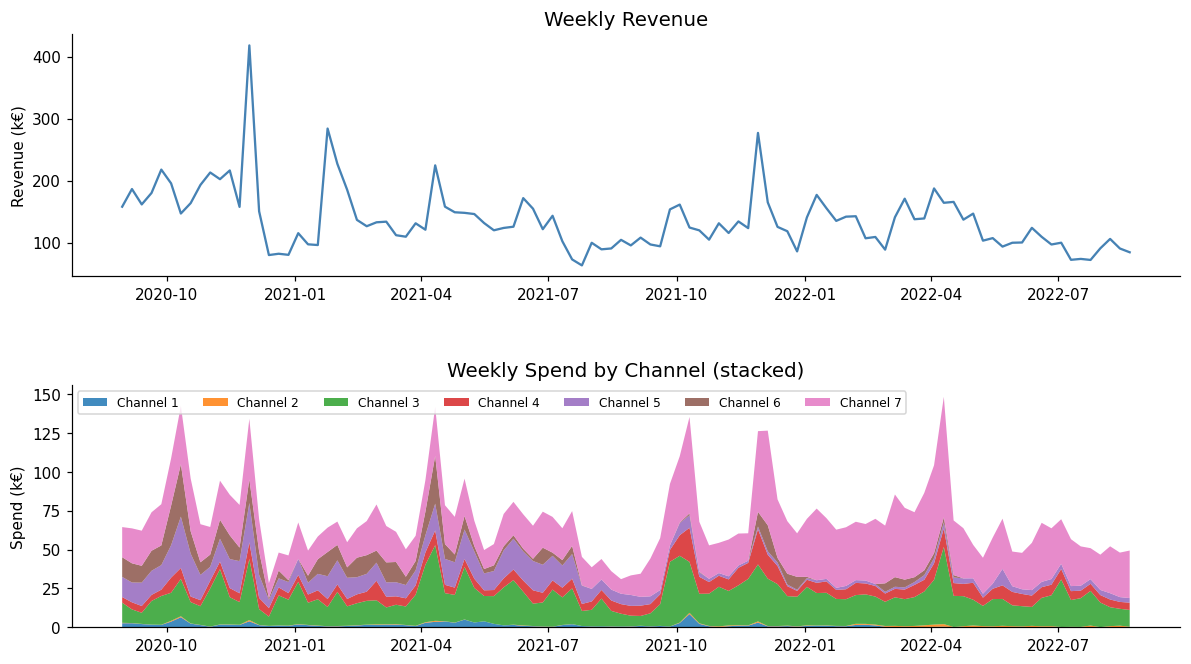

In [110]:
# Revenue over time + stacked channel spend
fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={'hspace': 0.45})

axes[0].plot(df.start_of_week, df.revenue / 1e3, color='steelblue', lw=1.5)
axes[0].set_title('Weekly Revenue', fontsize=13)
axes[0].set_ylabel('Revenue (k€)')

axes[1].stackplot(
    df.start_of_week,
    (df[CHANNELS] / 1e3).T,
    labels=[f'Channel {i}' for i in range(1, 8)],
    alpha=0.85
)
axes[1].set_title('Weekly Spend by Channel (stacked)', fontsize=13)
axes[1].set_ylabel('Spend (k€)')
axes[1].legend(loc='upper left', ncol=7, fontsize=8)

plt.savefig('timeseries.png', bbox_inches='tight')
plt.show()

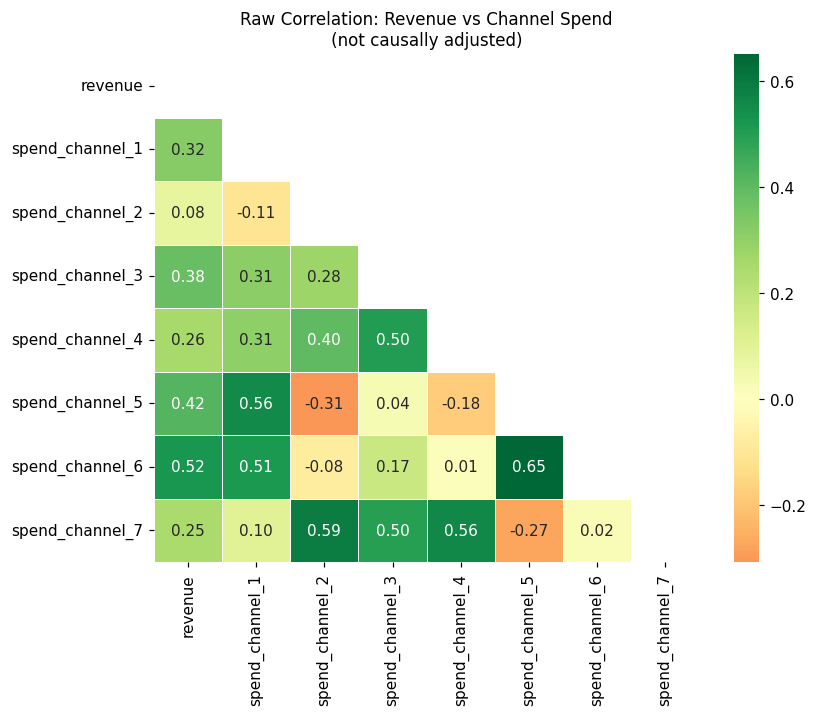

In [72]:
# Raw correlation heatmap — directional signal only, not causal
corr = df[['revenue'] + CHANNELS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (duplicate)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)
ax.set_title('Raw Correlation: Revenue vs Channel Spend\n(not causally adjusted)', fontsize=11)
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()

---
## 3. Prepare Model Inputs

Three things to prepare before building the model:

**Scaling** : MCMC works much better when all variables are on a similar scale (roughly 0–2). We divide revenue by its mean and each channel's spend by its maximum. The scale factors are saved so we can convert predictions back to euros later.

**Trend** : a linear index from 0.0 (week 1) to 1.0 (week 104), so the model can capture whether revenue is growing or shrinking over time.

**Fourier seasonality** : instead of 51 weekly dummy variables, we use 4 sine/cosine columns (2 frequency pairs) to approximate annual seasonal patterns. Same idea as Facebook Prophet.

####  --- Scale revenue ---

In [73]:
# Divide by mean so values cluster around 1.0
revenue_scale = df['revenue'].mean()
y = (df['revenue'].values / revenue_scale).astype(float)

#### --- Scale spend ---

In [74]:
# Divide each channel by its own max → all channels land in [0, 1]
spend_raw   = df[CHANNELS].values.astype(float)
spend_scale = spend_raw.max(axis=0)      # shape: (7,)
X_spend     = spend_raw / spend_scale    # shape: (104, 7)

#### --- Trend: ---
0.0 at week 1, 
1.0 at week 104 

In [78]:
trend = np.linspace(0, 1, N)

#### --- Fourier seasonality features ---

In [79]:
# For each harmonic k: sin(2*pi*k*t / 52) and cos(2*pi*k*t / 52)
# With n_order=2 we get 4 columns: [sin1, cos1, sin2, cos2]
def make_fourier_features(n_weeks, period=52, n_order=2):
    t = np.arange(n_weeks)
    cols = []
    for k in range(1, n_order + 1):
        cols.append(np.sin(2 * np.pi * k * t / period))
        cols.append(np.cos(2 * np.pi * k * t / period))
    return np.column_stack(cols)

N_FOURIER = 2
fourier   = make_fourier_features(N, period=52, n_order=N_FOURIER)

print(f'y (scaled revenue)  : {y.shape}  range {y.min():.2f}–{y.max():.2f}')
print(f'X_spend (scaled)    : {X_spend.shape}')
print(f'trend               : {trend.shape}')
print(f'fourier             : {fourier.shape}')
print(f'Revenue scale       : {revenue_scale:,.0f} euros')

y (scaled revenue)  : (104,)  range 0.46–3.06
X_spend (scaled)    : (104, 7)
trend               : (104,)
fourier             : (104, 4)
Revenue scale       : 136,490 euros


---
## 4. Adstock Function (Carry-Over Effect)

Ads don't just work in the week they run; a TV spot this week might still drive sales 3 weeks later. We model this with geometric adstock:

```
adstock[t] = spend[t] + lambda * adstock[t-1]
```

- `lambda = 0` → no carry-over, only this week's spend counts
- `lambda = 0.5` → half the effect carries forward each week (~2 week memory)
- `lambda = 0.9` → strong carry-over (~7 week memory, typical for TV)

The model **learns one lambda per channel** from data rather than fixing it manually.

We use `pytensor.scan` instead of a Python `for` loop because this function runs inside the PyMC model graph. PyTensor needs to trace through every operation to compute gradients for the NUTS sampler.

In [80]:
def geometric_adstock(spend_vector, decay_rate):
    """
    Geometric adstock for one channel — runs inside the PyMC model graph.

    Args:
        spend_vector : 1D PyTensor tensor of scaled weekly spend
        decay_rate   : scalar PyTensor variable in [0, 1]

    Returns:
        adstock : 1D tensor, same shape as spend_vector
    """
    def step(spend_t, adstock_prev, lam):
        return spend_t + lam * adstock_prev

    adstock, _ = pytensor.scan(
        fn=step,
        sequences=[spend_vector],
        outputs_info=[pt.zeros_like(spend_vector[0])], 
        non_sequences=[decay_rate]
    )
    return adstock

#### Quick manual demo to verify the formula makes sense

In [81]:
demo = np.zeros(5)
print(demo)

[0. 0. 0. 0. 0.]


In [82]:
demo[0] = 100
print(demo[0])

100.0


In [83]:
# Spend 100 in week 1, nothing after → effect should decay: 100, 50, 25, 12.5 ...
print('Adstock demo (lambda=0.5, spend=[100, 0, 0, 0, 0]):')

for t in range(1, 5):
    demo[t] = 0 + 0.5 * demo[t - 1]
for t, v in enumerate(demo):
    print(f'  week {t+1}: {v:.1f}')

Adstock demo (lambda=0.5, spend=[100, 0, 0, 0, 0]):
  week 1: 100.0
  week 2: 50.0
  week 3: 25.0
  week 4: 12.5
  week 5: 6.2


---
## 5. Build the Bayesian Model

In [84]:
with pm.Model() as mmm:

    # --- Data ---
    # pm.Data makes arrays visible to the model graph
    spend_data   = pm.Data('spend_data',   X_spend)   # (104, 7)
    trend_data   = pm.Data('trend_data',   trend)     # (104,)
    fourier_data = pm.Data('fourier_data', fourier)   # (104, 4)

    # --- Baseline ---
    intercept  = pm.Normal('intercept',  mu=1.0, sigma=0.3)
    beta_trend = pm.Normal('beta_trend', mu=0.0, sigma=0.3)

    # Seasonality: 4 Fourier weights summed into one seasonal curve
    gamma       = pm.Normal('gamma', mu=0, sigma=0.1, shape=2 * N_FOURIER)
    seasonality = pm.math.dot(fourier_data, gamma)   # (104,)

    # --- Channel parameters ---
    # One decay rate and one coefficient per channel
    lam     = pm.Beta('lam',     alpha=2, beta=2,  shape=7)  # carry-over rate
    beta_ch = pm.HalfNormal('beta_ch', sigma=0.5,  shape=7)  # revenue per adstock unit

    # Apply adstock to each channel, then stack into (104, 7)
    adstocked = pt.stack(
        [geometric_adstock(spend_data[:, c], lam[c]) for c in range(7)],
        axis=1
    )

    # Total media contribution: sum across all 7 channels
    media_contribution = pm.math.dot(adstocked, beta_ch)   # (104,)

    # --- Expected revenue ---
    mu = intercept + beta_trend * trend_data + seasonality + media_contribution

    # --- Likelihood ---
    # Revenue = expected revenue + Gaussian noise
    sigma = pm.HalfNormal('sigma', sigma=0.2)
    obs   = pm.Normal('obs', mu=mu, sigma=sigma, observed=y)

print(mmm.debug())

point={'intercept': array(1.), 'beta_trend': array(0.), 'gamma': array([0., 0., 0., 0.]), 'lam_logodds__': array([0., 0., 0., 0., 0., 0., 0.]), 'beta_ch_log__': array([-0.69314718, -0.69314718, -0.69314718, -0.69314718, -0.69314718,
       -0.69314718, -0.69314718]), 'sigma_log__': array(-1.60943791)}

No problems found
None


---
## 6. Prior Predictive Check

Before running MCMC, we verify that our priors produce plausible revenue values even without seeing any data.

We sample 500 parameter sets from the priors alone and plot the resulting revenue range. If the orange band roughly covers the observed blue line, the priors are reasonable. If it's way off (negative revenue, or 10× actual), we fix the priors before continuing.

Sampling: [beta_ch, beta_trend, gamma, intercept, lam, obs, sigma]


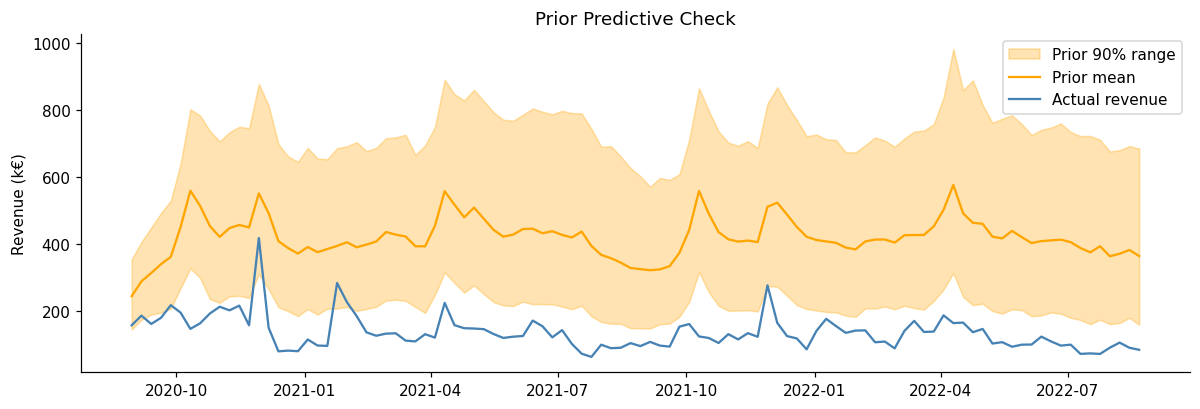

In [85]:
with mmm:
    prior_pred = pm.sample_prior_predictive(samples=500, random_seed=RANDOM_SEED)

# Shape (1, 500, 104) → (500, 104), then convert to euros
prior_samples = prior_pred.prior_predictive['obs'].values.squeeze() * revenue_scale

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(
    df.start_of_week,
    np.percentile(prior_samples, 5,  axis=0) / 1e3,
    np.percentile(prior_samples, 95, axis=0) / 1e3,
    alpha=0.3, color='orange', label='Prior 90% range'
)
ax.plot(df.start_of_week, prior_samples.mean(axis=0) / 1e3,
        color='orange', lw=1.5, label='Prior mean')
ax.plot(df.start_of_week, df.revenue / 1e3,
        color='steelblue', lw=1.5, label='Actual revenue')
ax.set_title('Prior Predictive Check', fontsize=12)
ax.set_ylabel('Revenue (k€)')
ax.legend()
plt.savefig('prior_predictive.png', bbox_inches='tight')
plt.show()

---
## 7. Fit the Model with MCMC

MCMC (Markov Chain Monte Carlo) finds the posterior distribution; our updated beliefs about all parameters after seeing 104 weeks of data. PyMC uses the **NUTS sampler**, which works well for continuous parameters.

- `draws=1000`, `tune=1000` : 1000 warm-up steps (discarded) + 1000 kept per chain
- `chains=4` : run 4 independent chains; agreement between them confirms convergence
- `target_accept=0.9` : higher = more careful sampling

Total output: **4 × 1000 = 4000 posterior samples** per parameter.

In [86]:
with mmm:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        idata_kwargs={'log_likelihood': True} 
    )

print(az.summary(
    trace,
    var_names=['intercept', 'beta_trend', 'lam', 'beta_ch', 'sigma'],
    round_to=3
))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_trend, gamma, lam, beta_ch, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 153 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept   0.578  0.128   0.327    0.810      0.003    0.002  2118.558   
beta_trend -0.333  0.178  -0.670    0.000      0.004    0.003  1983.788   
lam[0]      0.434  0.213   0.064    0.801      0.003    0.003  4277.252   
lam[1]      0.379  0.200   0.046    0.743      0.004    0.003  3206.540   
lam[2]      0.295  0.177   0.017    0.623      0.003    0.003  3361.959   
lam[3]      0.332  0.198   0.025    0.696      0.003    0.003  3807.998   
lam[4]      0.316  0.166   0.046    0.620      0.003    0.003  3010.040   
lam[5]      0.358  0.190   0.021    0.689      0.003    0.002  4545.754   
lam[6]      0.349  0.192   0.026    0.697      0.003    0.003  3672.503   
beta_ch[0]  0.061  0.058   0.000    0.170      0.001    0.001  2641.236   
beta_ch[1]  0.228  0.140   0.001    0.473      0.003    0.002  2270.050   
beta_ch[2]  0.276  0.165   0.000    0.549      0.003    0.002  2358.167   
beta_ch[3]  0.158  0.136 

---
## 8. Convergence Check

Two diagnostics to confirm the sampler worked correctly:

**R-hat**: compares variance within each chain to variance between chains.
- R-hat ≈ 1.00 → all 4 chains agree → converged 
- R-hat > 1.01 → chains disagree → do not trust the results

**ESS (Effective Sample Size)**: MCMC draws are correlated, so 4000 draws ≠ 4000 independent samples. ESS estimates the equivalent number of independent samples.
- ESS > 400 → sufficient for reliable estimates 

**Trace plots**: the sampling path per chain should look like random noise with all 4 chains overlapping.

In [88]:
summary  = az.summary(trace, var_names=['intercept', 'beta_trend', 'lam', 'beta_ch', 'sigma'])
max_rhat = summary['r_hat'].max()
min_ess  = summary['ess_bulk'].min()

print('=== CONVERGENCE ===')
print(f'Max R-hat : {max_rhat:.4f}  (target < 1.01)  →  {"PASS" if max_rhat < 1.01 else "FAIL"}')
print(f'Min ESS   : {min_ess:.0f}    (target > 400)   →  {"PASS" if min_ess > 400 else "FAIL"}')

=== CONVERGENCE ===
Max R-hat : 1.0000  (target < 1.01)  →  PASS
Min ESS   : 1336    (target > 400)   →  PASS


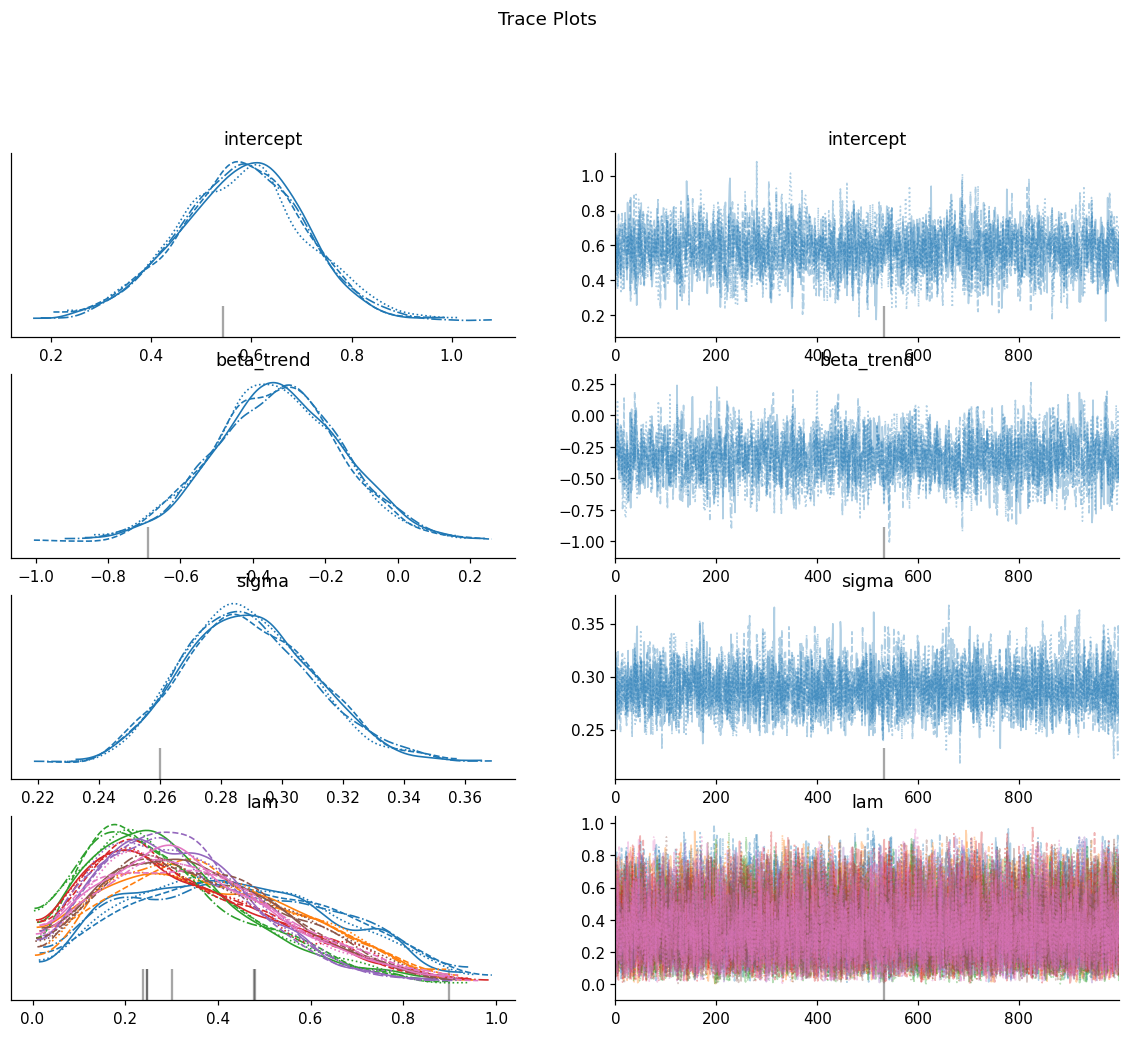

In [89]:
# Left: posterior distributions | Right: sampling paths (should look like noise)
az.plot_trace(
    trace,
    var_names=['intercept', 'beta_trend', 'sigma', 'lam'],
    compact=True,
    figsize=(13, 10)
)
plt.suptitle('Trace Plots', y=1.01)
plt.savefig('trace.png', bbox_inches='tight')
plt.show()

---
## 9. Posterior Predictive Check and Model Fit

We use the fitted model to simulate revenue draws and compare them to the actuals.

**Fit metrics:**
- **R²** : proportion of variance explained (1.0 = perfect)
- **MAPE** : mean absolute % error; easy to communicate to stakeholders
- **RMSE** : root mean squared error in euros
- **WAIC / LOO** : Bayesian out-of-sample accuracy estimates (higher = better); used to compare model variants

Sampling: [obs]


Output()

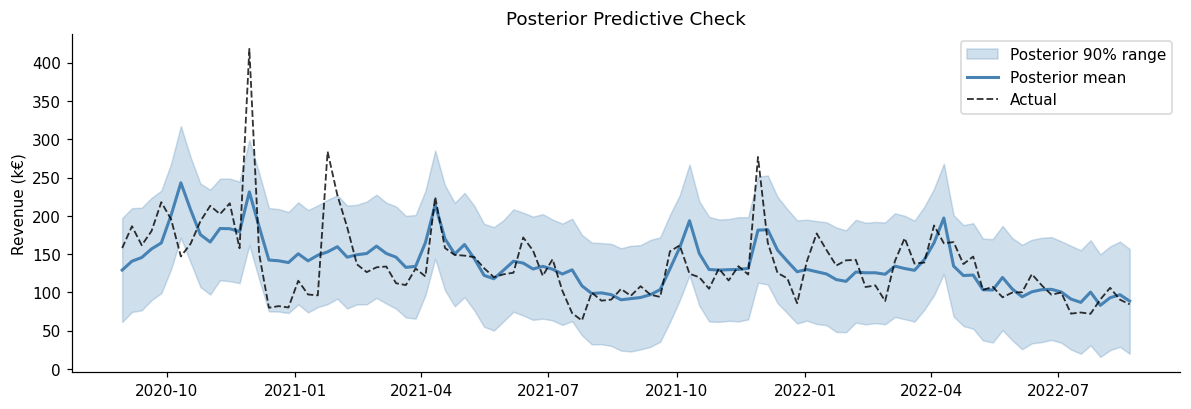

In [90]:
with mmm:
    post_pred = pm.sample_posterior_predictive(trace, random_seed=RANDOM_SEED)

# (4 chains, 1000 draws, 104 weeks) → (4000, 104) → euros
pp      = post_pred.posterior_predictive['obs'].values.reshape(-1, N) * revenue_scale
pp_mean = pp.mean(axis=0)
pp_lo   = np.percentile(pp, 5,  axis=0)
pp_hi   = np.percentile(pp, 95, axis=0)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(df.start_of_week, pp_lo / 1e3, pp_hi / 1e3,
                alpha=0.25, color='steelblue', label='Posterior 90% range')
ax.plot(df.start_of_week, pp_mean / 1e3,
        color='steelblue', lw=2, label='Posterior mean')
ax.plot(df.start_of_week, df.revenue / 1e3,
        color='black', lw=1.2, ls='--', alpha=0.8, label='Actual')
ax.set_title('Posterior Predictive Check', fontsize=12)
ax.set_ylabel('Revenue (k€)')
ax.legend()
plt.savefig('fig_05_posterior_predictive.png', bbox_inches='tight')
plt.show()

In [93]:
y_obs = df.revenue.values
y_hat = pp_mean

r2   = 1 - np.sum((y_obs - y_hat) ** 2) / np.sum((y_obs - y_obs.mean()) ** 2)
mape = np.mean(np.abs((y_obs - y_hat) / y_obs)) * 100
rmse = np.sqrt(np.mean((y_obs - y_hat) ** 2))
waic = az.waic(trace)
loo  = az.loo(trace)

print('Metrics:')
print(f'R²   : {r2:.4f}')
print(f'MAPE : {mape:.1f}%')
print(f'RMSE : {rmse:,.0f} euros')
print(f'WAIC : {waic.elpd_waic:.1f}  (higher = better)')
print(f'LOO  : {loo.elpd_loo:.1f}  (higher = better)')

Metrics:
R²   : 0.4441
MAPE : 19.4%
RMSE : 37,701 euros
WAIC : -27.3  (higher = better)
LOO  : -27.3  (higher = better)


---
## 10. Revenue Attribution

Using posterior mean parameters, we split total revenue into:
- **Baseline**: revenue from intercept + trend + seasonality (exists even with zero ad spend)
- **Channel contributions**: revenue driven by each channel's adstock effect

We also extract the **adstock decay rates** here:
- High lambda (close to 1) → long carry-over → typical of TV / brand campaigns
- Low lambda (close to 0) → near-immediate effect → typical of paid search / direct response
- **Half-life** = weeks until the effect drops to 50% of its initial value

In [96]:
# --- Extract posterior means ---
intercept_mean  = trace.posterior['intercept'].values.mean()
beta_trend_mean = trace.posterior['beta_trend'].values.mean()
gamma_mean      = trace.posterior['gamma'].values.reshape(-1, 2 * N_FOURIER).mean(axis=0)

# (4 chains × 1000 draws × 7 channels) → (4000, 7)
lam_samples  = trace.posterior['lam'].values.reshape(-1, 7)
beta_samples = trace.posterior['beta_ch'].values.reshape(-1, 7)
lam_mean     = lam_samples.mean(axis=0)
beta_mean    = beta_samples.mean(axis=0)

# Decay rate credible intervals
lam_lo = np.percentile(lam_samples, 5,  axis=0)
lam_hi = np.percentile(lam_samples, 95, axis=0)

# Half-life: lambda^t = 0.5  →  t = log(0.5) / log(lambda)
half_life = np.log(0.5) / np.log(lam_mean + 1e-9)

print('Adstock decay rates (posterior):')
print(pd.DataFrame({
    'Channel'          : [f'Channel {i}' for i in range(1, 8)],
    'lambda (mean)'    : lam_mean.round(3),
    'lambda (5%)'      : lam_lo.round(3),
    'lambda (95%)'     : lam_hi.round(3),
    'half-life (weeks)': half_life.round(1)
}).to_string(index=False))

Adstock decay rates (posterior):
  Channel  lambda (mean)  lambda (5%)  lambda (95%)  half-life (weeks)
Channel 1          0.434        0.110         0.796                0.8
Channel 2          0.379        0.087         0.736                0.7
Channel 3          0.295        0.059         0.634                0.6
Channel 4          0.332        0.068         0.703                0.6
Channel 5          0.316        0.079         0.615                0.6
Channel 6          0.358        0.081         0.703                0.7
Channel 7          0.349        0.076         0.709                0.7


In [97]:
# --- Numpy adstock for post-hoc calculations (outside the model graph) ---
def adstock_numpy(spend, lam):
    result = np.zeros_like(spend)
    result[0] = spend[0]
    for t in range(1, len(spend)):
        result[t] = spend[t] + lam * result[t - 1]
    return result

# Adstock matrix with posterior mean lambdas — shape: (104, 7)
adstock_matrix = np.column_stack([
    adstock_numpy(X_spend[:, c], lam_mean[c]) for c in range(7)
])

# Channel contributions in euros
channel_contrib_eur = (adstock_matrix * beta_mean) * revenue_scale  # (104, 7)

# Baseline in euros
baseline_eur = (
    intercept_mean + beta_trend_mean * trend + fourier @ gamma_mean
) * revenue_scale

# Attribution summary table
total_revenue  = df.revenue.sum()
channel_totals = channel_contrib_eur.sum(axis=0)

attr_df = pd.DataFrame({
    'Component'    : ['Baseline'] + [f'Channel {i}' for i in range(1, 8)],
    'Revenue (k€)' : np.round(
        np.concatenate([[baseline_eur.sum()], channel_totals]) / 1e3, 1
    )
})
attr_df['Share (%)'] = (attr_df['Revenue (k€)'] * 1e3 / total_revenue * 100).round(1)

print(f'Total observed revenue: {total_revenue / 1e6:.2f}M euros')
print()
print(attr_df.to_string(index=False))

Total observed revenue: 14.19M euros

Component  Revenue (k€)  Share (%)
 Baseline        5845.8       41.2
Channel 1         225.0        1.6
Channel 2        1104.9        7.8
Channel 3        2172.2       15.3
Channel 4        1022.1        7.2
Channel 5        1432.7       10.1
Channel 6         715.4        5.0
Channel 7        1808.7       12.7


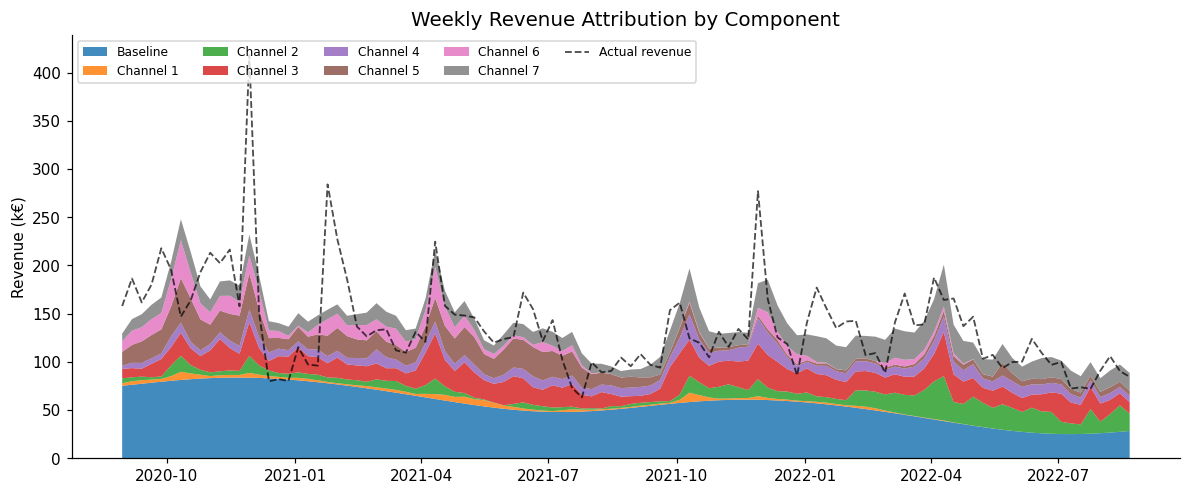

In [98]:
# Stacked area chart of weekly attribution
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    df.start_of_week,
    [baseline_eur / 1e3] + [channel_contrib_eur[:, c] / 1e3 for c in range(7)],
    labels=['Baseline'] + [f'Channel {i}' for i in range(1, 8)],
    colors=colors[:8],
    alpha=0.85
)
ax.plot(df.start_of_week, df.revenue / 1e3,
        color='black', lw=1.2, ls='--', alpha=0.7, label='Actual revenue')
ax.set_title('Weekly Revenue Attribution by Component', fontsize=13)
ax.set_ylabel('Revenue (k€)')
ax.legend(loc='upper left', ncol=5, fontsize=8)
plt.savefig('attribution.png', bbox_inches='tight')
plt.show()

---
## 11. ROI Analysis

```
ROI per channel = revenue attributed to that channel / total euros spent on it
```

- ROI = 1.0 → break-even
- ROI = 4.0 → every €1 spent generated €4 in revenue
- ROI < 1.0 → loss-making channel

Because we have 4000 posterior samples, we compute ROI for each sample and report the full distribution — giving us a **90% credible interval** on each channel's ROI rather than just a single number.

In [99]:
total_spend = df[CHANNELS].sum().values  # total euros per channel over 2 years

# Point estimate from posterior means
roi_mean = channel_totals / total_spend

# Uncertainty: compute ROI for each of the 4000 posterior samples
n_post  = lam_samples.shape[0]
roi_all = np.zeros((n_post, 7))

for s in range(n_post):
    ads_s = np.column_stack([
        adstock_numpy(X_spend[:, c], lam_samples[s, c]) for c in range(7)
    ])
    rev_s = (ads_s * beta_samples[s]).sum(axis=0) * revenue_scale
    roi_all[s] = rev_s / total_spend

roi_lo = np.percentile(roi_all, 5,  axis=0)
roi_hi = np.percentile(roi_all, 95, axis=0)

roi_df = pd.DataFrame({
    'Channel'             : [f'Channel {i}' for i in range(1, 8)],
    'Spend (k€)'          : (total_spend / 1e3).round(1),
    'Attributed Rev (k€)' : (channel_totals / 1e3).round(1),
    'ROI mean'            : roi_mean.round(2),
    'ROI 5%'              : roi_lo.round(2),
    'ROI 95%'             : roi_hi.round(2),
}).sort_values('ROI mean', ascending=False).reset_index(drop=True)

print('Channel ROI — ranked best to worst:')
print(roi_df.to_string(index=False))
print()
print(f"Best channel: {roi_df.iloc[0]['Channel']}  (ROI = {roi_df.iloc[0]['ROI mean']:.2f}x)")

Channel ROI — ranked best to worst:
  Channel  Spend (k€)  Attributed Rev (k€)  ROI mean  ROI 5%  ROI 95%
Channel 2        35.7               1104.9     30.92    5.20    62.97
Channel 1       129.5                225.0      1.74    0.10     5.54
Channel 5       891.9               1432.7      1.61    0.20     3.10
Channel 4       719.2               1022.1      1.42    0.10     3.28
Channel 6       526.6                715.4      1.36    0.17     2.87
Channel 3      2028.7               2172.2      1.07    0.18     2.05
Channel 7      2880.9               1808.7      0.63    0.07     1.37

Best channel: Channel 2  (ROI = 30.92x)


---
## 12. Time-Based Holdout Validation

**Why not a random train/test split?**

Two reasons this would be wrong here:
1. **Adstock is recursive** — week 90's adstock value depends on week 89, which depends on week 88, all the way back to week 1. Shuffling rows breaks this chain completely.
2. **Future leaks into the past** — if week 100 is in the training set, the model effectively uses future spend patterns when predicting past revenue.

**Correct approach:** Hold out the last 26 weeks. Refit the model on weeks 1–78 only, then predict weeks 79–104.

**Key adstock detail:** When predicting the holdout period, we still need to compute adstock over the full 104-week series — then slice the last 26 rows. If we started adstock from week 79, we'd assume zero advertising history and predictions would be systematically too low.

**Coverage metric:** A well-calibrated Bayesian model should have ~90% of actual values fall inside its 90% credible interval.

#### --- Define the split ---

In [101]:
HOLDOUT_WEEKS = 26  # last ~25% of data

train_idx = slice(0, N - HOLDOUT_WEEKS)   # weeks 1–78
test_idx  = slice(N - HOLDOUT_WEEKS, N)   # weeks 79–104

y_train       = y[train_idx]
X_train       = X_spend[train_idx]
trend_train   = trend[train_idx]
fourier_train = fourier[train_idx]

n_train = N - HOLDOUT_WEEKS
print(f'Training : weeks 1–{n_train}')
print(f'Holdout  : weeks {n_train + 1}–{N}')

Training : weeks 1–78
Holdout  : weeks 79–104


#### --- Refit the model on training data only ---

In [102]:
# Identical model spec to Section 5 — only the data slices change
with pm.Model() as mmm_train:

    spend_data_tr   = pm.Data('spend_data',   X_train)
    trend_data_tr   = pm.Data('trend_data',   trend_train)
    fourier_data_tr = pm.Data('fourier_data', fourier_train)

    intercept  = pm.Normal('intercept',  mu=1.0, sigma=0.3)
    beta_trend = pm.Normal('beta_trend', mu=0.0, sigma=0.3)
    gamma      = pm.Normal('gamma', mu=0, sigma=0.1, shape=2 * N_FOURIER)
    seasonality = pm.math.dot(fourier_data_tr, gamma)

    lam     = pm.Beta('lam',    alpha=2, beta=2, shape=7)
    beta_ch = pm.HalfNormal('beta_ch', sigma=0.5, shape=7)

    adstocked_tr = pt.stack(
        [geometric_adstock(spend_data_tr[:, c], lam[c]) for c in range(7)], axis=1
    )
    media_contribution = pm.math.dot(adstocked_tr, beta_ch)

    mu    = intercept + beta_trend * trend_data_tr + seasonality + media_contribution
    sigma = pm.HalfNormal('sigma', sigma=0.2)
    obs   = pm.Normal('obs', mu=mu, sigma=sigma, observed=y_train)

with mmm_train:
    trace_train = pm.sample(
        draws=1000, tune=1000, chains=4,
        target_accept=0.9, random_seed=RANDOM_SEED
    )

print('Training model fitted.')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_trend, gamma, lam, beta_ch, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 105 seconds.


Training model fitted.


In [112]:

# Adstock is computed over the FULL 104 weeks, then we slice the holdout rows.
# This preserves the training history that week 79 onward depends on.

lam_post        = trace_train.posterior['lam'].values.reshape(-1, 7)
beta_post       = trace_train.posterior['beta_ch'].values.reshape(-1, 7)
intercept_post  = trace_train.posterior['intercept'].values.flatten()
beta_trend_post = trace_train.posterior['beta_trend'].values.flatten()
gamma_post      = trace_train.posterior['gamma'].values.reshape(-1, 2 * N_FOURIER)

holdout_preds = np.zeros((lam_post.shape[0], HOLDOUT_WEEKS))

for s in range(lam_post.shape[0]):
    # Full-series adstock → slice holdout rows
    ads_full    = np.column_stack([
        adstock_numpy(X_spend[:, c], lam_post[s, c]) for c in range(7)
    ])
    ads_holdout = ads_full[test_idx]  # (26, 7) — already carries training history

    media  = (ads_holdout * beta_post[s]).sum(axis=1)
    season = fourier[test_idx] @ gamma_post[s]
    mu_s   = intercept_post[s] + beta_trend_post[s] * trend[test_idx] + season + media

    holdout_preds[s] = mu_s * revenue_scale

pred_mean     = holdout_preds.mean(axis=0)
pred_lo       = np.percentile(holdout_preds, 5,  axis=0)
pred_hi       = np.percentile(holdout_preds, 95, axis=0)
y_holdout_eur = y[test_idx] * revenue_scale

print('Holdout predictions ready.')

Holdout predictions ready.


#### --- Generate holdout predictions ---

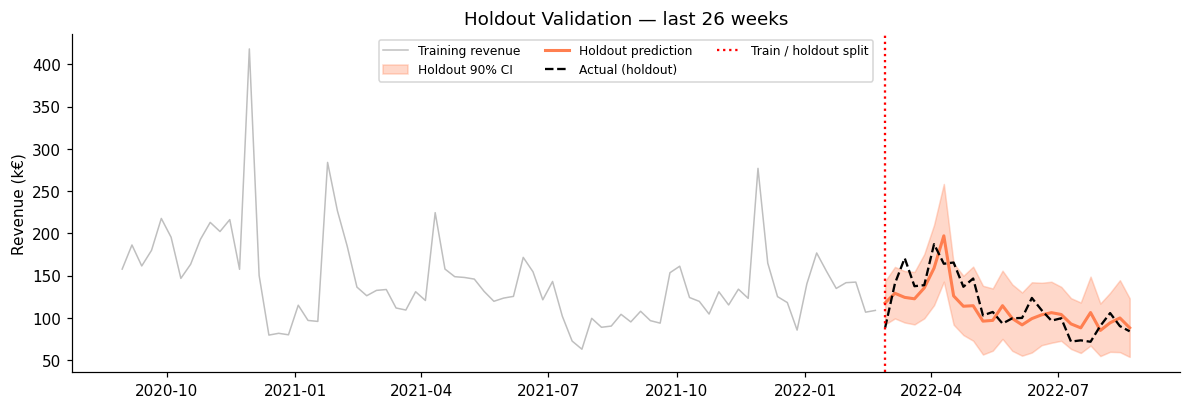

In [113]:
# --- Plot: training context + holdout predictions vs actuals ---
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(df.start_of_week[train_idx], df.revenue[train_idx] / 1e3,
        color='gray', lw=1, alpha=0.5, label='Training revenue')

ax.fill_between(df.start_of_week[test_idx], pred_lo / 1e3, pred_hi / 1e3,
                alpha=0.3, color='coral', label='Holdout 90% CI')
ax.plot(df.start_of_week[test_idx], pred_mean / 1e3,
        color='coral', lw=2, label='Holdout prediction')
ax.plot(df.start_of_week[test_idx], y_holdout_eur / 1e3,
        color='black', lw=1.5, ls='--', label='Actual (holdout)')

ax.axvline(df.start_of_week.iloc[n_train], color='red', lw=1.5,
           ls=':', label='Train / holdout split')
ax.set_title(f'Holdout Validation — last {HOLDOUT_WEEKS} weeks', fontsize=12)
ax.set_ylabel('Revenue (k€)')
ax.legend(ncol=3, fontsize=8)
plt.savefig('fig_08_holdout.png', bbox_inches='tight')
plt.show()

In [114]:
# --- Holdout metrics ---
r2_ho   = 1 - np.sum((y_holdout_eur - pred_mean) ** 2) / np.sum((y_holdout_eur - y_holdout_eur.mean()) ** 2)
mape_ho = np.mean(np.abs((y_holdout_eur - pred_mean) / y_holdout_eur)) * 100
rmse_ho = np.sqrt(np.mean((y_holdout_eur - pred_mean) ** 2))

# Coverage: what % of actuals fall inside the 90% CI?
# Target ~90% — much lower = overconfident, much higher = too uncertain
coverage = np.mean((y_holdout_eur >= pred_lo) & (y_holdout_eur <= pred_hi)) * 100

print('HOLDOUT METRICS:')
print(f'R²       : {r2_ho:.4f}')
print(f'MAPE     : {mape_ho:.1f}%')
print(f'RMSE     : {rmse_ho:,.0f} euros')
print(f'Coverage : {coverage:.0f}%  (target ~90%)')

HOLDOUT METRICS:
R²       : 0.5534
MAPE     : 15.2%
RMSE     : 21,402 euros
Coverage : 88%  (target ~90%)


---
## 13. Final Summary

In [115]:
print('=' * 60)
print('BAYESIAN MMM — KEY RESULTS')
print('=' * 60)

print('\nIN-SAMPLE FIT (all 104 weeks)')
print(f'  R²   : {r2:.3f}')
print(f'  MAPE : {mape:.1f}%')
print(f'  RMSE : {rmse:,.0f} euros')

print(f'\nHOLDOUT FIT (trained wks 1–{n_train}, tested wks {n_train+1}–{N})')
print(f'  R²       : {r2_ho:.3f}')
print(f'  MAPE     : {mape_ho:.1f}%')
print(f'  RMSE     : {rmse_ho:,.0f} euros')
print(f'  Coverage : {coverage:.0f}%  (target ~90%)')

print(f'\nREVENUE ATTRIBUTION  (total {total_revenue / 1e6:.2f}M euros)')
for _, row in attr_df.iterrows():
    bar = '|' * int(row['Share (%)'] / 2)
    print(f"  {row['Component']:<12}  {row['Revenue (k€)']:7.0f} k   {row['Share (%)']:5.1f}%  {bar}")

print('\nADSTOCK DECAY (posterior mean)')
for i in range(7):
    print(f'  Channel {i+1}: lambda = {lam_mean[i]:.3f}  half-life ~ {half_life[i]:.1f} weeks')

print('\nROI RANKING')
for _, row in roi_df.iterrows():
    print(f"  {row['Channel']}: {row['ROI mean']:.2f}x  "
          f"(90% CI: {row['ROI 5%']:.2f}–{row['ROI 95%']:.2f})")

print(f"\nBest channel: {roi_df.iloc[0]['Channel']}  ROI = {roi_df.iloc[0]['ROI mean']:.2f}x")
print('=' * 60)

BAYESIAN MMM — KEY RESULTS

IN-SAMPLE FIT (all 104 weeks)
  R²   : 0.444
  MAPE : 19.4%
  RMSE : 37,701 euros

HOLDOUT FIT (trained wks 1–78, tested wks 79–104)
  R²       : 0.553
  MAPE     : 15.2%
  RMSE     : 21,402 euros
  Coverage : 88%  (target ~90%)

REVENUE ATTRIBUTION  (total 14.19M euros)
  Baseline         5846 k    41.2%  ||||||||||||||||||||
  Channel 1         225 k     1.6%  
  Channel 2        1105 k     7.8%  |||
  Channel 3        2172 k    15.3%  |||||||
  Channel 4        1022 k     7.2%  |||
  Channel 5        1433 k    10.1%  |||||
  Channel 6         715 k     5.0%  ||
  Channel 7        1809 k    12.7%  ||||||

ADSTOCK DECAY (posterior mean)
  Channel 1: lambda = 0.434  half-life ~ 0.8 weeks
  Channel 2: lambda = 0.379  half-life ~ 0.7 weeks
  Channel 3: lambda = 0.295  half-life ~ 0.6 weeks
  Channel 4: lambda = 0.332  half-life ~ 0.6 weeks
  Channel 5: lambda = 0.316  half-life ~ 0.6 weeks
  Channel 6: lambda = 0.358  half-life ~ 0.7 weeks
  Channel 7: lambda 

---
## Challenge Questions — Answers

**Q1: How do you model spend carry over?**
Geometric adstock: `adstock[t] = spend[t] + lambda * adstock[t-1]`. One lambda is learned per channel using a `Beta(2,2)` prior. Implemented with `pytensor.scan` so it runs inside the model graph and gradients can be computed for the NUTS sampler.

**Q2: Explain your choice of prior inputs to the model?**
- `HalfNormal` on channel betas: ad spend can only help revenue, not hurt it, so the effect must be non-negative.
- `Beta(2,2)` on lambda: naturally bounded in [0,1], centred at 0.5, avoids degenerate zero or infinite carry-over.
- `Normal(1.0, 0.3)` on intercept: revenue is scaled to mean ~1.0, so this prior anchors the baseline there.
- All widths are permissive enough to let the data dominate, but not so flat they cause sampling problems.

**Q3: How are your model results based on prior sampling vs. posterior sampling?**
The prior predictive (Section 6) shows wide uncertainty that spans the observed revenue range, priors are vague enough to not dominate. After fitting (Section 9), the posterior credible band is much tighter and tracks the actual revenue closely. The narrowing represents information learned from 104 weeks of data.

**Q4: How good is your model performing? How you do measure it?**
- **In-sample**: R², MAPE, RMSE (Section 9). WAIC/LOO as Bayesian out-of-sample proxies.
  - R²   : 0.4441
  - MAPE : 19.4%
  - RMSE : 37,701 euros
  - WAIC : -27.3  (higher = better)
  - LOO  : -27.3  (higher = better)
- **Convergence**: R-hat < 1.01 and ESS > 400 (Section 8).
  - Max R-hat : 1.0000  (target < 1.01)  →  PASS
  - Min ESS   : 1336    (target > 400)   →  PASS
- **True out-of-sample**: time-based holdout with coverage metric (Section 12).
  - R² : 0.5534
  - MAPE : 15.2%
  - RMSE : 21,402 euros
  - Coverage : 88%  (target ~90%)

**Q5: What are your main insights in terms of channel performance/ effects?**
Channels with high lambda have long carry-over. Channels with low lambda have near-immediate effects (direct response). Revenue shares and half-lives are in Section 10.

**Q6: Can you derive ROI (return on investment) estimates per channel? What is the best channel in terms of ROI?**
ROI = attributed revenue / total spend. Computed across all 4000 posterior samples to produce a full uncertainty distribution. Best channel and full ranking is **channel 2  (ROI = 30.92x)**.